### Deep Learning Final Project

### Deep Learning Regression for Stellar Age Estimation of Red Giant Stars

In [1]:
import os
os.makedirs('plots', exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Astronomy data access
from astroquery.vizier import Vizier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

/Users/nakulpandit/Desktop/Modules/deep learning/final Project/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
# Loading the APO-K2 stellar age catalog from VizieR
catalog_id = "J/AJ/167/208/table3"

vizier = Vizier(
    columns=[
        "EPIC", "GaiaEDR3", "Teff", "e_Teff", "logg", "e_logg",
        "[Fe/H]", "e_[Fe/H]", "[a/M]", "e_[a/M]", "[O/Fe]", "e_[O/Fe]",
        "Mstar", "e_Mstar", "Rstar", "e_Rstar", "logg-seis", "e_logg-seis",
        "numax", "e_numax", "deltanu", "e_deltanu",
        "Age", "e_Age", "E_Age", "Age-mode"
    ],
    row_limit=-1
)

tables = vizier.get_catalogs(catalog_id)
table = tables[0]
df = table.to_pandas()

print("Shape:", df.shape)
print(df.head())
print(df.columns.tolist())

Shape: (1912, 26)
        EPIC             GaiaEDR3  Teff  e_Teff  logg  e_logg  [Fe/H]  \
0  211837778   656372815030872192  4759       9  2.38    0.02  -0.306   
1  210915682    58475709154017280  4757       9  2.44    0.03  -0.335   
2  210352614    37590412768055040  4755       9  2.36    0.03  -0.556   
3  214710068  4073182748305313536  4643      10  2.18    0.03  -0.774   
4  212351370  3607531430651890048  4999      11  2.47    0.03  -0.461   

   e_[Fe/H]  [a/M]  e_[a/M]  ...  logg-seis  e_logg-seis      numax  e_numax  \
0     0.008  0.063    0.006  ...       2.45         0.01  35.000000      0.9   
1     0.008  0.077    0.007  ...       2.48         0.01  37.700001      0.5   
2     0.008  0.123    0.008  ...       2.44         0.01  34.400002      0.7   
3     0.010  0.301    0.010  ...       2.18         0.01  19.100000      0.5   
4     0.008  0.104    0.007  ...       2.55         0.01  42.599998      0.7   

   deltanu  e_deltanu   Age  e_Age      E_Age  Age-mode  
0   

In [3]:
# Cleaning column names and inspecting the missing values

df = df.rename(columns={
    "Teff": "teff",
    "e_Teff": "teff_err",
    "logg": "logg_spec",
    "e_logg": "logg_spec_err",
    "[Fe/H]": "feh",
    "e_[Fe/H]": "feh_err",
    "[a/M]": "alpha_m",
    "e_[a/M]": "alpha_m_err",
    "[O/Fe]": "o_fe",
    "e_[O/Fe]": "o_fe_err",
    "Mstar": "mass",
    "e_Mstar": "mass_err",
    "Rstar": "radius",
    "e_Rstar": "radius_err",
    "logg-seis": "logg_seis",
    "e_logg-seis": "logg_seis_err",
    "Age": "age_median",
    "e_Age": "age_err_low",
    "E_Age": "age_err_high",
    "Age-mode": "age_mode"
})

print(df.info())
print("\nMissing values:\n", df.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1912 entries, 0 to 1911
Data columns (total 26 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   EPIC           1912 non-null   int32  
 1   GaiaEDR3       1912 non-null   int64  
 2   teff           1912 non-null   int16  
 3   teff_err       1912 non-null   int16  
 4   logg_spec      1912 non-null   float32
 5   logg_spec_err  1912 non-null   float32
 6   feh            1912 non-null   float32
 7   feh_err        1912 non-null   float32
 8   alpha_m        1912 non-null   float32
 9   alpha_m_err    1912 non-null   float32
 10  o_fe           1912 non-null   float32
 11  o_fe_err       1912 non-null   float32
 12  mass           1912 non-null   float32
 13  mass_err       1912 non-null   float32
 14  radius         1912 non-null   float32
 15  radius_err     1912 non-null   float32
 16  logg_seis      1912 non-null   float32
 17  logg_seis_err  1912 non-null   float32
 18  numax   

In [4]:
# Defining Target

# Selected input features
feature_cols = [
    "teff",
    "logg_spec",
    "feh",
    "alpha_m",
    "o_fe",
    "mass",
    "radius",
    "logg_seis",
    "numax",
    "deltanu"
]

target_col = "age_mode"
error_cols = [
    "teff_err", "logg_spec_err", "feh_err", "alpha_m_err", "o_fe_err",
    "mass_err", "radius_err", "logg_seis_err", "e_numax", "e_deltanu",
    "age_err_low", "age_err_high"
]

use_cols = feature_cols + [target_col] + error_cols

data = df[use_cols].copy()
print(data.head())

   teff  logg_spec    feh  alpha_m   o_fe  mass  radius  logg_seis      numax  \
0  4759       2.38 -0.306    0.063  0.105  1.49   12.00       2.45  35.000000   
1  4757       2.44 -0.335    0.077  0.159  1.26   10.65       2.48  37.700001   
2  4755       2.36 -0.556    0.123  0.259  0.95    9.68       2.44  34.400002   
3  4643       2.18 -0.774    0.301  0.369  0.81   12.05       2.18  19.100000   
4  4999       2.47 -0.461    0.104  0.201  1.34   10.20       2.55  42.599998   

   deltanu  ...  feh_err  alpha_m_err  o_fe_err  mass_err  radius_err  \
0     3.97  ...    0.008        0.006     0.018      0.12        0.31   
1     4.37  ...    0.008        0.007     0.019      0.23        0.61   
2     4.38  ...    0.008        0.008     0.020      0.17        0.56   
3     2.91  ...    0.010        0.010     0.023      0.25        1.17   
4     4.80  ...    0.008        0.007     0.027      0.15        0.35   

   logg_seis_err  e_numax  e_deltanu  age_err_low  age_err_high  
0       

In [ ]:
# Data cleaning and physically sensible filtering

data = data.dropna(subset=feature_cols + [target_col]).copy()

# Removing obviously non-physical or extreme target values

data = data[(data["age_mode"] > 0.0) & (data["age_mode"] <= 20.0)]

# Removing rows with invalid seismic quantities
data = data[(data["numax"] > 0) & (data["deltanu"] > 0)]

# Removing stars with very large age uncertainty if available
if "age_err_low" in data.columns and "age_err_high" in data.columns:
    data = data[(data["age_err_low"] < 5.0) & (data["age_err_high"] < 5.0)]

print("Cleaned shape:", data.shape)
print(data.describe())

Cleaned shape: (936, 23)
              teff   logg_spec         feh     alpha_m        o_fe  \
count   936.000000  936.000000  936.000000  936.000000  936.000000   
mean   4701.530983    2.369338   -0.304338    0.113724    0.164438   
std     204.546027    0.248243    0.259624    0.095616    0.140254   
min    4175.000000    1.520000   -0.999000    0.000000   -0.531000   
25%    4554.750000    2.210000   -0.479000    0.035000    0.057750   
50%    4695.500000    2.380000   -0.301000    0.082000    0.133000   
75%    4842.250000    2.520000   -0.127000    0.197250    0.264250   
max    5374.000000    3.270000    0.505000    0.387000    0.813000   

             mass      radius   logg_seis       numax     deltanu  ...  \
count  936.000000  936.000000  936.000000  936.000000  936.000000  ...   
mean     1.331389   12.411443    2.393066   35.397011    4.001624  ...   
std      0.332136    3.538416    0.235654   20.814911    1.623964  ...   
min      0.780000    5.350000    1.680000    6.1

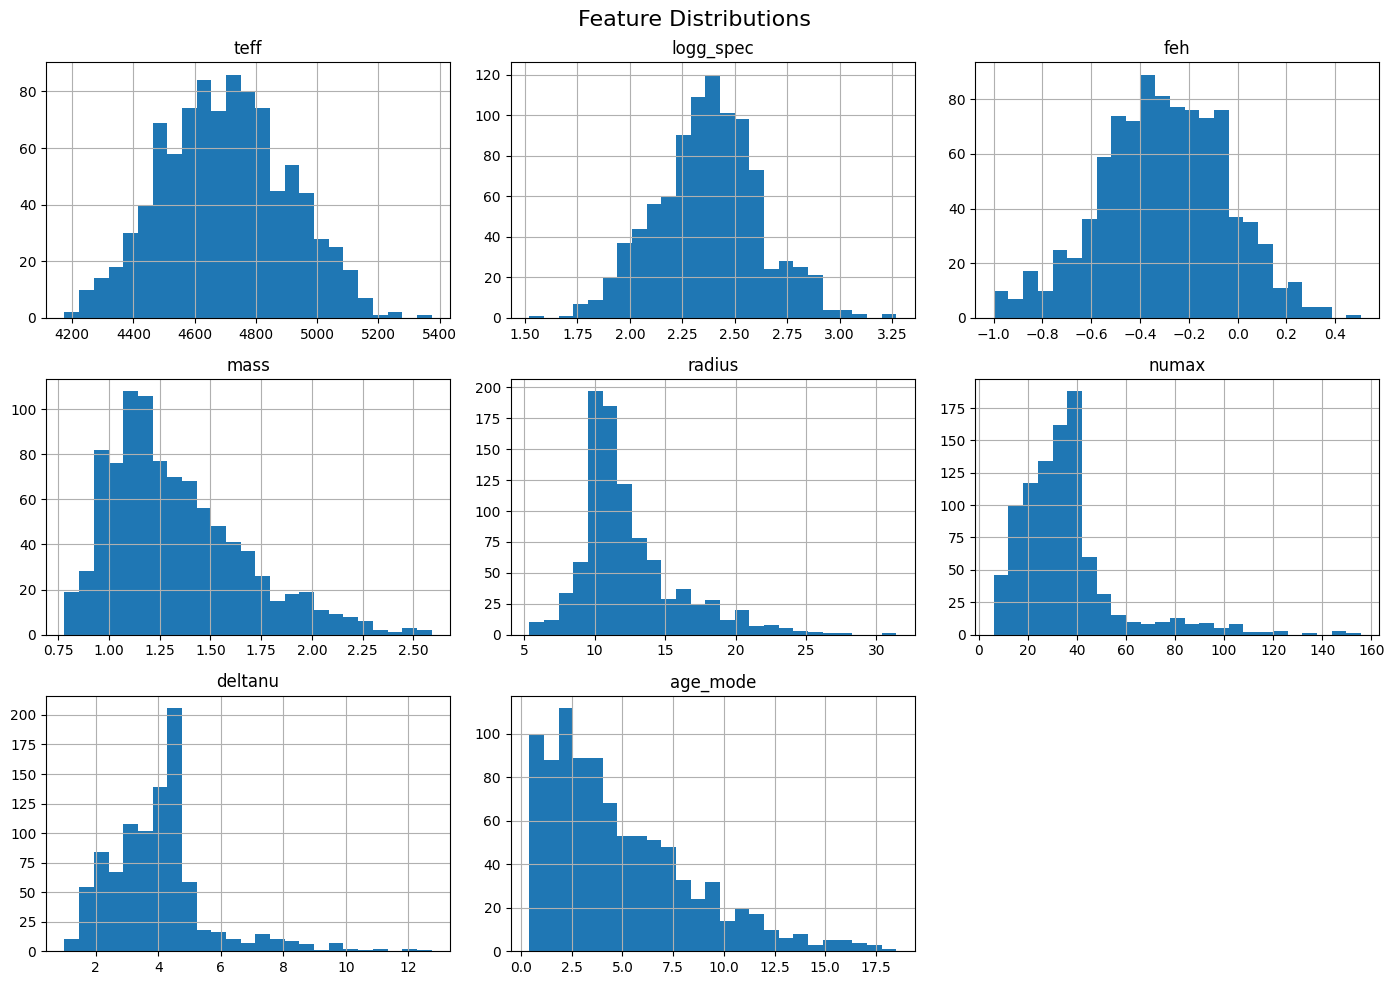

In [6]:
# Histograms of important features
data[["teff", "logg_spec", "feh", "mass", "radius", "numax", "deltanu", "age_mode"]].hist(
    figsize=(14, 10), bins=25
)
plt.suptitle("Feature Distributions", fontsize=16)
plt.tight_layout()
plt.savefig('plots/feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

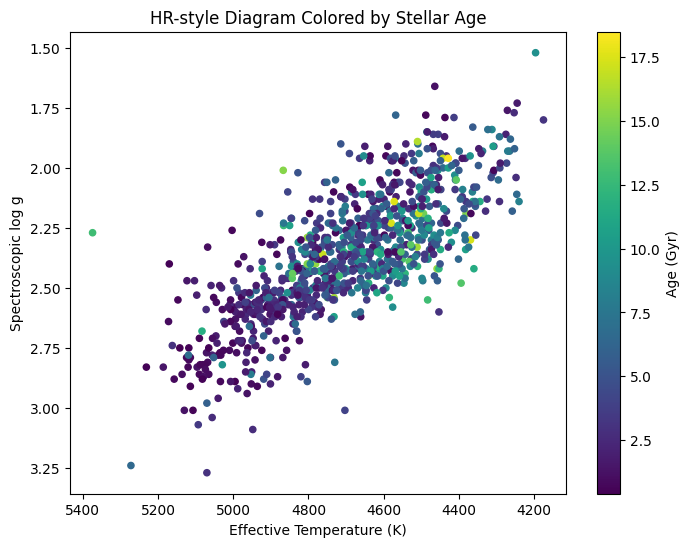

In [ ]:
# HR-style diagram: Teff vs logg (common stellar diagnostic view)
plt.figure(figsize=(8, 6))
plt.scatter(data["teff"], data["logg_spec"], c=data["age_mode"], s=20)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel("Effective Temperature (K)")
plt.ylabel("Spectroscopic log g")
plt.title("HR-style Diagram Colored by Stellar Age")
plt.colorbar(label="Age (Gyr)")
plt.savefig('plots/hr_style_diagram_colored_by_stellar_age.png', dpi=150, bbox_inches='tight')
plt.show()

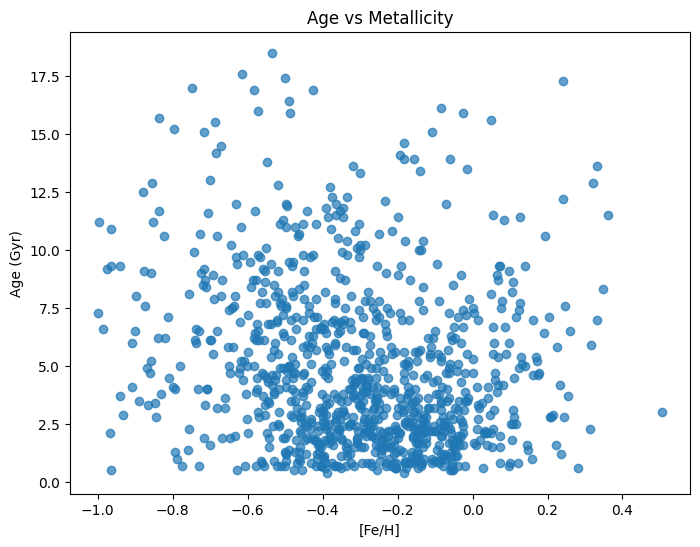

In [8]:
# Age vs metallicity
plt.figure(figsize=(8, 6))
plt.scatter(data["feh"], data["age_mode"], alpha=0.7)
plt.xlabel("[Fe/H]")
plt.ylabel("Age (Gyr)")
plt.title("Age vs Metallicity")
plt.savefig('plots/age_vs_metallicity.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
X = data[feature_cols].copy()
y = data[target_col].copy()

# Train/temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Validation/test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (655, 10)
Validation shape: (140, 10)
Test shape: (141, 10)


In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [11]:
baseline_model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="linear")
])

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,777 (46.00 KB)

 Trainable params: 11,777 (46.00 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

history = baseline_model.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=300,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/300



 1/21 ━━━━━━━━━━━━━━━━━━━━ 11s 595ms/step - loss: 29.4142 - mae: 4.6023


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 28.6384 - mae: 4.0804 - val_loss: 19.1452 - val_mae: 3.2588 - learning_rate: 0.0010


Epoch 2/300



 1/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.9074 - mae: 2.7042

...


21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - loss: 0.3073 - mae: 0.3786 - val_loss: 0.1348 - val_mae: 0.2695 - learning_rate: 6.2500e-05


Epoch 125/300



 1/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1912 - mae: 0.3328


Epoch 125: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.



21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 978us/step - loss: 0.2984 - mae: 0.3764 - val_loss: 0.1711 - val_mae: 0.3015 - learning_rate: 6.2500e-05


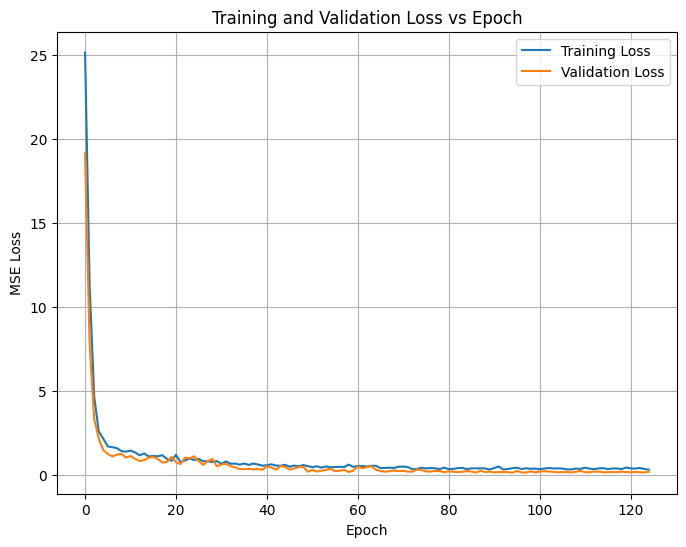

In [ ]:
# Train & Val Loss v/s Epoch Plot
plt.figure(figsize=(8, 6))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training and Validation Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.savefig('plots/training_and_validation_loss_vs_epoch.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
y_pred = baseline_model.predict(X_test_scaled).flatten()

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Test MSE  : {mse:.4f}")
print(f"Test RMSE : {rmse:.4f}")
print(f"Test MAE  : {mae:.4f}")
print(f"Test R^2  : {r2:.4f}")


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


Test MSE  : 0.1709
Test RMSE : 0.4134
Test MAE  : 0.2747
Test R^2  : 0.9853


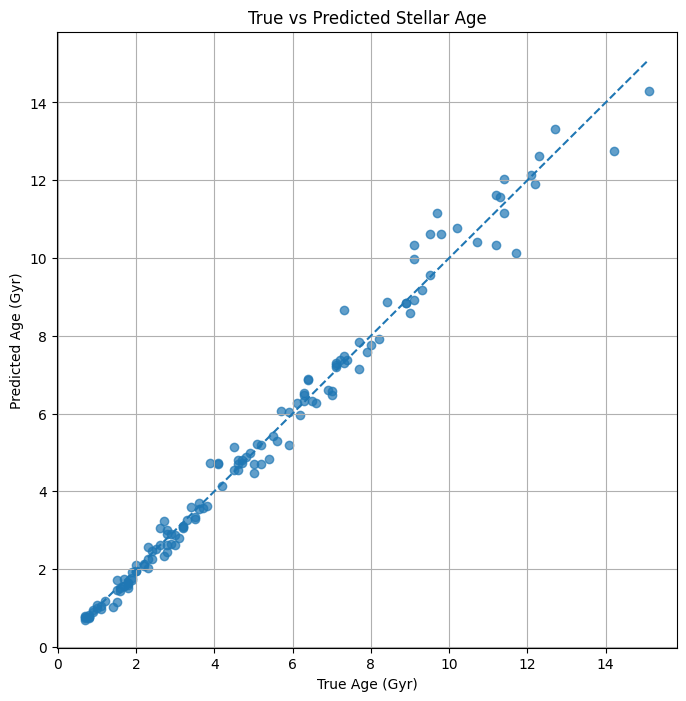

In [ ]:
# True v/s Predicted Stellar Age
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.7)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")
plt.xlabel("True Age (Gyr)")
plt.ylabel("Predicted Age (Gyr)")
plt.title("True vs Predicted Stellar Age")
plt.grid(True)
plt.savefig('plots/true_vs_predicted_stellar_age.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# True vs Predicted Stellar Age (Line Comparison)
y_test_flat = y_test.values.flatten()
y_pred_flat = y_pred.flatten()

# Sort for cleaner visualization
sorted_idx = np.argsort(y_test_flat)
y_test_sorted = y_test_flat[sorted_idx]
y_pred_sorted = y_pred_flat[sorted_idx]

plt.figure(figsize=(10, 5))
plt.plot(y_test_sorted, label="True Values")
plt.plot(y_pred_sorted, label="Predicted Values")
plt.xlabel("Sample Index (sorted by true age)")
plt.ylabel("Stellar Age (Gyr)")
plt.title("True vs Predicted Stellar Age (Line Comparison)")
plt.legend()
plt.grid(True)
plt.savefig("plots/true_vs_predicted_line_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

NameError: name 'y_test' is not defined

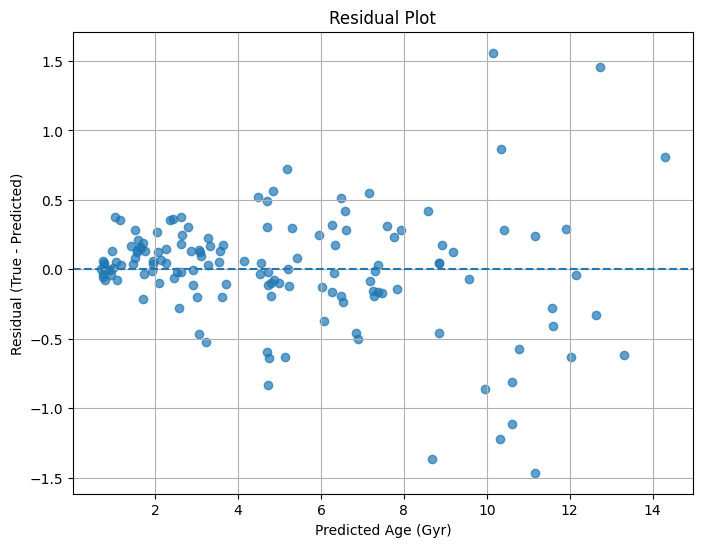

In [16]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted Age (Gyr)")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residual Plot")
plt.grid(True)
plt.savefig('plots/residual_plot.png', dpi=150, bbox_inches='tight')
plt.show()

In [1]:
plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=25)
plt.xlabel("Residual (Gyr)")
plt.ylabel("Count")
plt.title("Distribution of Test Residuals")
plt.grid(True)
plt.savefig('plots/distribution_of_test_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

In [2]:
test_results = X_test.copy()
test_results["true_age"] = y_test.values
test_results["pred_age"] = y_pred
test_results["abs_error"] = np.abs(test_results["true_age"] - test_results["pred_age"])

plt.figure(figsize=(8, 6))
plt.scatter(test_results["feh"], test_results["abs_error"], alpha=0.7)
plt.xlabel("[Fe/H]")
plt.ylabel("Absolute Error (Gyr)")
plt.title("Absolute Error vs Metallicity")
plt.grid(True)
plt.savefig('plots/absolute_error_vs_metallicity.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'X_test' is not defined

In [ ]:
test_results["teff"] = X_test["teff"].values
test_results["logg_spec"] = X_test["logg_spec"].values

plt.figure(figsize=(8, 6))
plt.scatter(test_results["teff"], test_results["logg_spec"], c=test_results["pred_age"], s=25)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel("Effective Temperature (K)")
plt.ylabel("Spectroscopic log g")
plt.title("HR-style Diagram Colored by Predicted Age")
plt.colorbar(label="Predicted Age (Gyr)")
plt.savefig('plots/hr_style_diagram_colored_by_predicted_age.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'X_test' is not defined

In [21]:
def build_model(hidden_units=[64, 32], dropout_rate=0.2, learning_rate=1e-3):
    model = Sequential()
    model.add(Input(shape=(X_train_scaled.shape[1],)))
    
    for units in hidden_units:
        model.add(Dense(units, activation="relu"))
        model.add(Dropout(dropout_rate))
    
    model.add(Dense(1, activation="linear"))
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=["mae"]
    )
    return model

architectures = {
    "small": [32, 16],
    "medium": [128, 64, 32],
    "large": [256, 128, 64, 32]
}

comparison_results = []

for name, arch in architectures.items():
    model = build_model(hidden_units=arch, dropout_rate=0.2, learning_rate=1e-3)
    
    history_tmp = model.fit(
        X_train_scaled, y_train,
        validation_data=(X_val_scaled, y_val),
        epochs=200,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )
    
    pred_tmp = model.predict(X_test_scaled, verbose=0).flatten()
    rmse_tmp = np.sqrt(mean_squared_error(y_test, pred_tmp))
    mae_tmp = mean_absolute_error(y_test, pred_tmp)
    r2_tmp = r2_score(y_test, pred_tmp)
    
    comparison_results.append({
        "model": name,
        "architecture": arch,
        "rmse": rmse_tmp,
        "mae": mae_tmp,
        "r2": r2_tmp
    })

comparison_df = pd.DataFrame(comparison_results)
print(comparison_df)

NameError: name 'Sequential' is not defined

In [5]:
plt.figure(figsize=(8, 6))
plt.bar(comparison_df["model"], comparison_df["rmse"])
plt.xlabel("Model")
plt.ylabel("Test RMSE")
plt.title("Architecture Comparison")
plt.grid(axis="y")
plt.savefig('plots/architecture_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'plt' is not defined

---
## Additional Diagnostic Visualisations

In [6]:
# 1. Correlation Heatmap of Input Features + Target
import seaborn as sns

corr_cols = feature_cols + [target_col]
corr_matrix = data[corr_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5
)
plt.title('Pearson Correlation Heatmap (Features + Target)', fontsize=14)
plt.tight_layout()
plt.savefig('plots/pearson_correlation_heatmap_features_target.png', dpi=150, bbox_inches='tight')
plt.show()

NameError: name 'feature_cols' is not defined

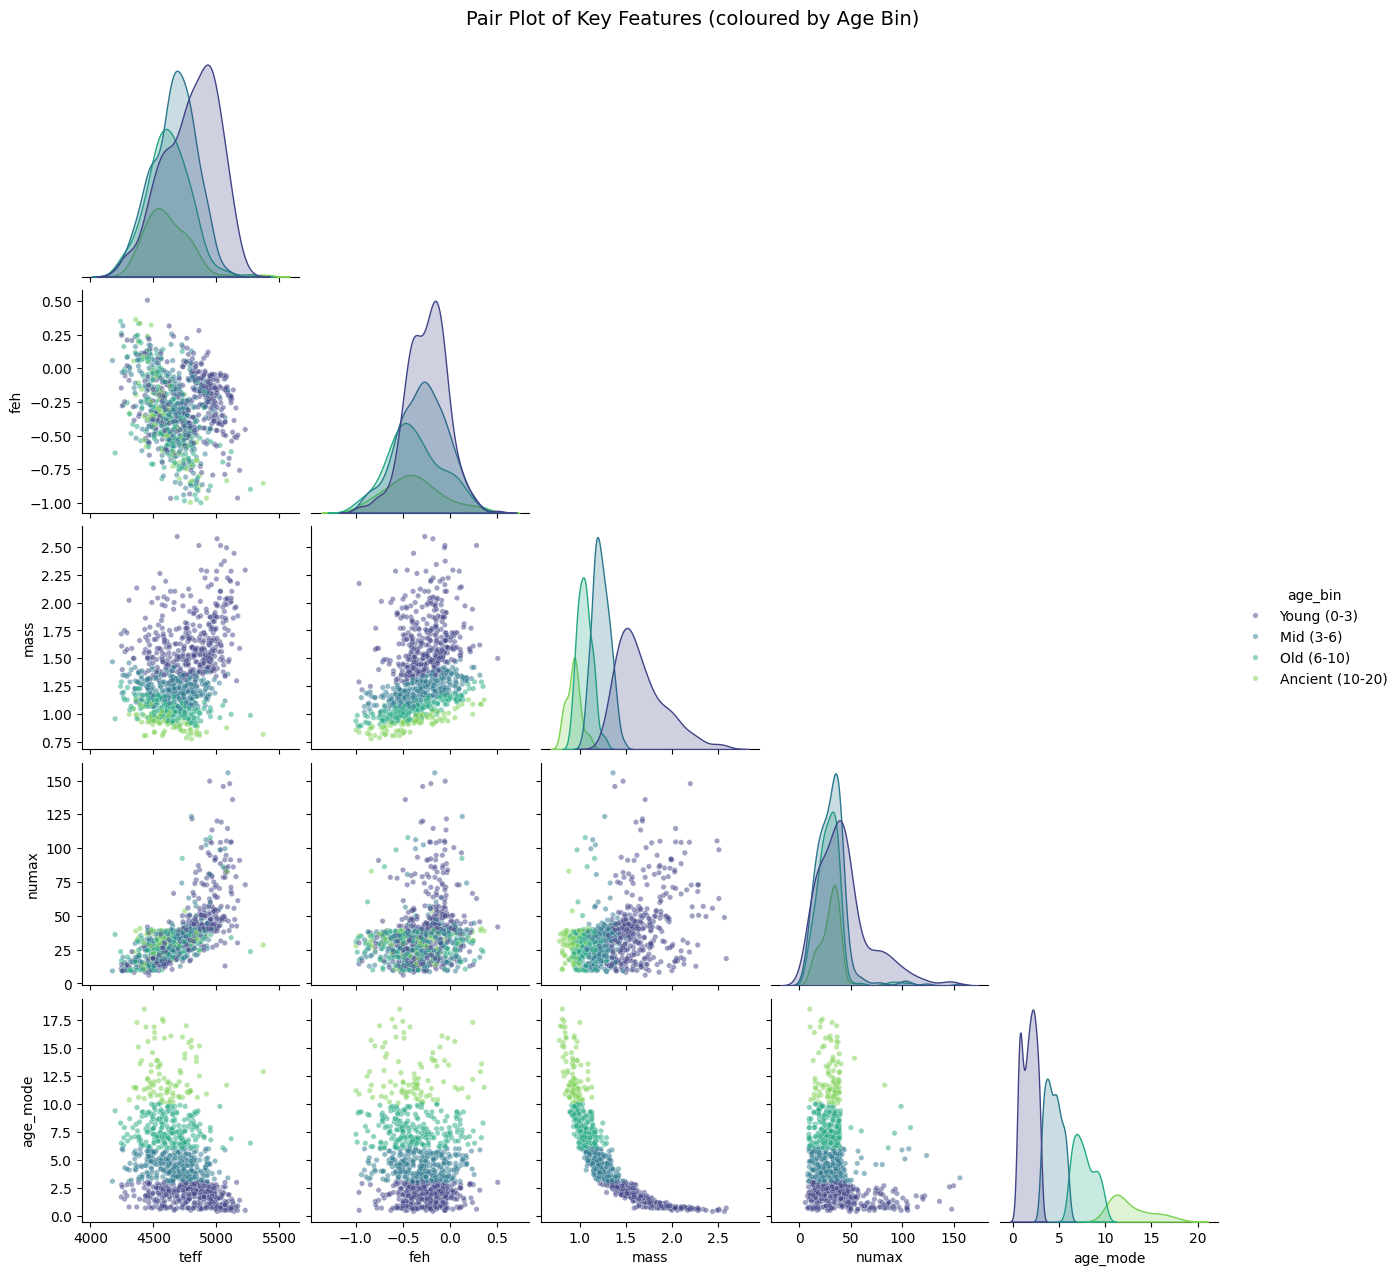

In [23]:
# 2. Pair Plot of Selected Key Features coloured by Age
pair_cols = ['teff', 'feh', 'mass', 'numax', 'age_mode']
pair_data = data[pair_cols].copy()

# Bin age into categories for colouring
pair_data['age_bin'] = pd.cut(
    pair_data['age_mode'],
    bins=[0, 3, 6, 10, 20],
    labels=['Young (0-3)', 'Mid (3-6)', 'Old (6-10)', 'Ancient (10-20)']
)

g = sns.pairplot(
    pair_data,
    hue='age_bin',
    palette='viridis',
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 15},
    corner=True
)
g.figure.suptitle('Pair Plot of Key Features (coloured by Age Bin)', y=1.02, fontsize=14)
plt.savefig('plots/pair_plot_of_key_features_coloured_by_age_bin.png', dpi=150, bbox_inches='tight')
plt.show()

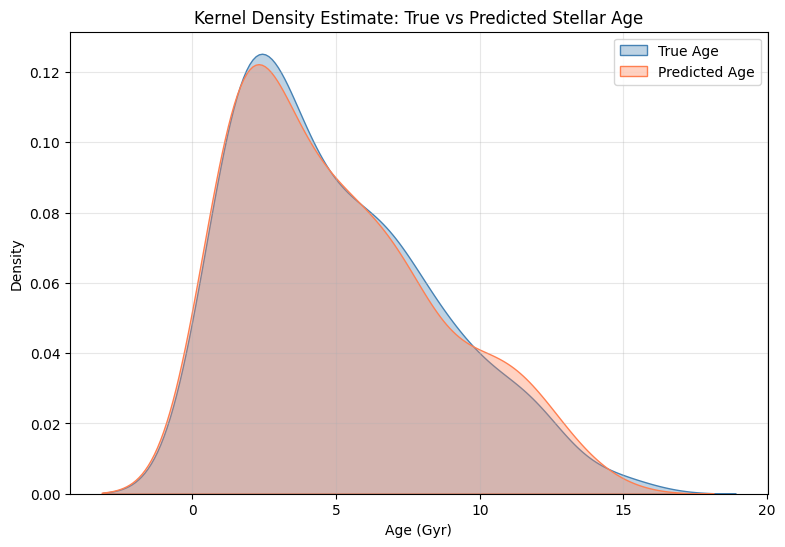

In [24]:
# 3. KDE Overlay: True vs Predicted Age Distribution
plt.figure(figsize=(9, 6))
sns.kdeplot(y_test, label='True Age', fill=True, alpha=0.35, color='steelblue')
sns.kdeplot(y_pred, label='Predicted Age', fill=True, alpha=0.35, color='coral')
plt.xlabel('Age (Gyr)')
plt.ylabel('Density')
plt.title('Kernel Density Estimate: True vs Predicted Stellar Age')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plots/kernel_density_estimate_true_vs_predicted_stellar_age.png', dpi=150, bbox_inches='tight')
plt.show()

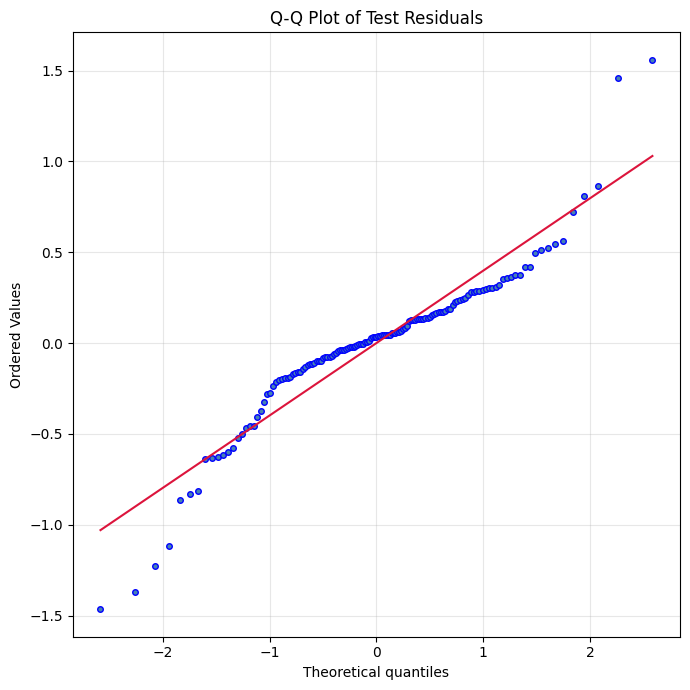

In [25]:
# 4. Q-Q Plot of Residuals (check for normality)
from scipy import stats

fig, ax = plt.subplots(figsize=(7, 7))
stats.probplot(residuals.values, dist='norm', plot=ax)
ax.set_title('Q-Q Plot of Test Residuals')
ax.get_lines()[0].set_markerfacecolor('steelblue')
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('crimson')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/q_q_plot_of_test_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

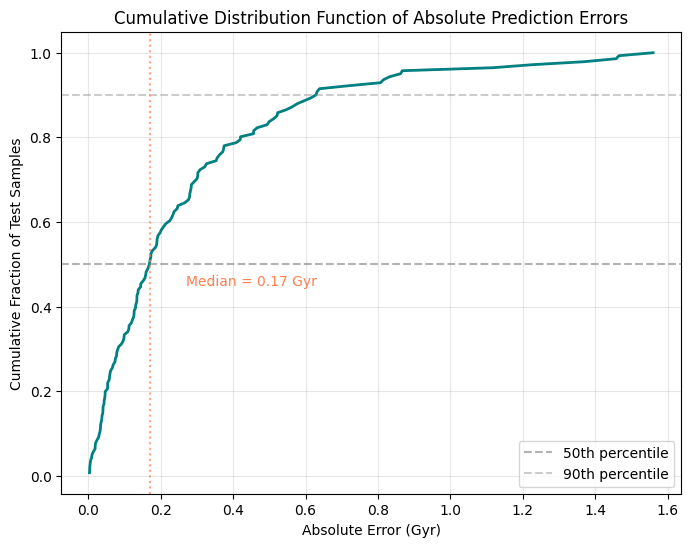

In [26]:
# 5. Cumulative Distribution of Absolute Errors
abs_errors = np.abs(y_test.values - y_pred)
sorted_err = np.sort(abs_errors)
cdf = np.arange(1, len(sorted_err) + 1) / len(sorted_err)

plt.figure(figsize=(8, 6))
plt.plot(sorted_err, cdf, linewidth=2, color='teal')
plt.axhline(0.5, linestyle='--', color='grey', alpha=0.6, label='50th percentile')
plt.axhline(0.9, linestyle='--', color='grey', alpha=0.4, label='90th percentile')

# Annotate the median error
median_err = np.median(abs_errors)
plt.axvline(median_err, linestyle=':', color='coral', alpha=0.7)
plt.text(median_err + 0.1, 0.45, f'Median = {median_err:.2f} Gyr', fontsize=10, color='coral')

plt.xlabel('Absolute Error (Gyr)')
plt.ylabel('Cumulative Fraction of Test Samples')
plt.title('Cumulative Distribution Function of Absolute Prediction Errors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('plots/cumulative_distribution_function_of_absolute_prediction_errors.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/1j/6168x29956dgb6w5h22437l00000gn/T/ipykernel_98257/2415867960.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='age_bin', y='abs_error', data=test_results_tmp,


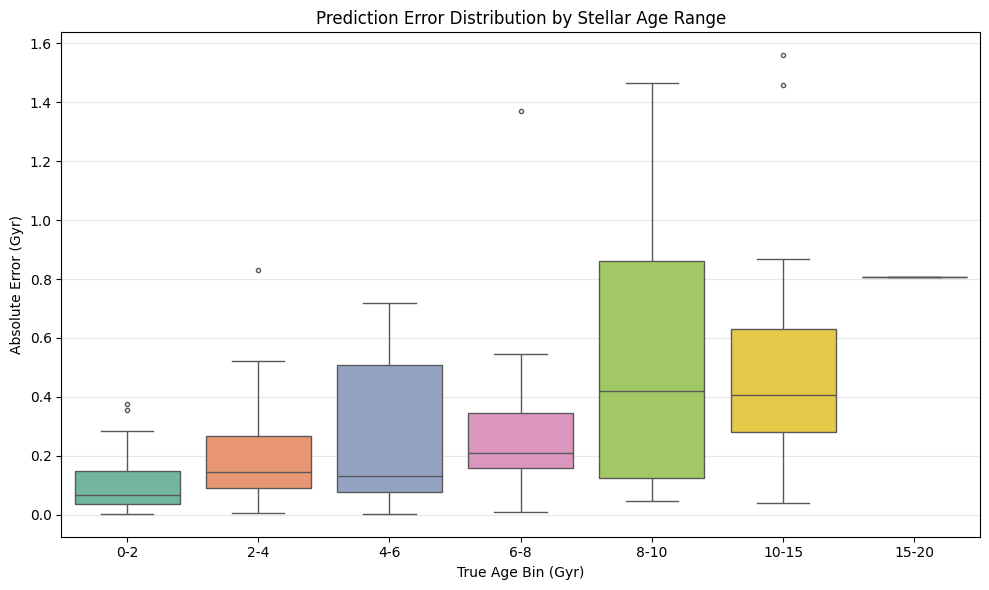

In [27]:
# 6. Box Plot of Absolute Error grouped by True-Age Bins
test_results_tmp = pd.DataFrame({
    'true_age': y_test.values,
    'abs_error': np.abs(y_test.values - y_pred)
})
test_results_tmp['age_bin'] = pd.cut(
    test_results_tmp['true_age'],
    bins=[0, 2, 4, 6, 8, 10, 15, 20],
    labels=['0-2', '2-4', '4-6', '6-8', '8-10', '10-15', '15-20']
)

plt.figure(figsize=(10, 6))
sns.boxplot(x='age_bin', y='abs_error', data=test_results_tmp,
            palette='Set2', fliersize=3)
plt.xlabel('True Age Bin (Gyr)')
plt.ylabel('Absolute Error (Gyr)')
plt.title('Prediction Error Distribution by Stellar Age Range')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/prediction_error_distribution_by_stellar_age_range.png', dpi=150, bbox_inches='tight')
plt.show()


1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step



1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step



1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step

...


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step



1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step



1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


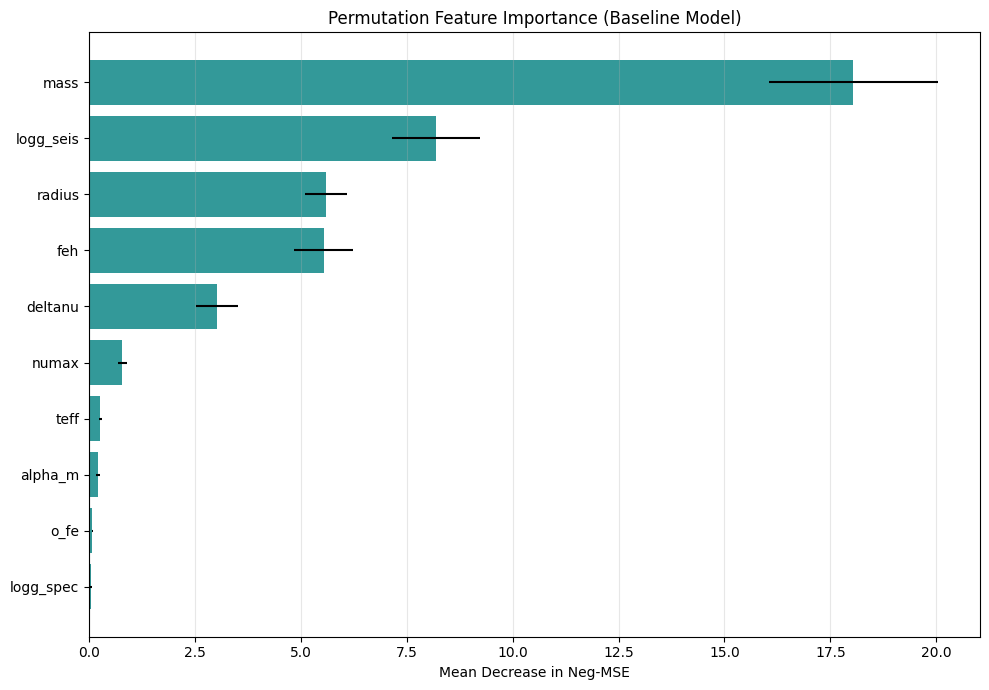

In [28]:
# 7. Permutation Feature Importance
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    baseline_model, X_test_scaled, y_test,
    n_repeats=15, random_state=42,
    scoring='neg_mean_squared_error'
)

sorted_idx = perm_result.importances_mean.argsort()

plt.figure(figsize=(10, 7))
plt.barh(
    [feature_cols[i] for i in sorted_idx],
    perm_result.importances_mean[sorted_idx],
    xerr=perm_result.importances_std[sorted_idx],
    color='teal', alpha=0.8
)
plt.xlabel('Mean Decrease in Neg-MSE')
plt.title('Permutation Feature Importance (Baseline Model)')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plots/permutation_feature_importance_baseline_model.png', dpi=150, bbox_inches='tight')
plt.show()